Restarted PINN_torch (Python 3.9.0)

In [ ]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/home/wergillius/Project/PINN_dynamics")


# ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=53-total_loss=0.21702482.ckpt"
ckpt_path = "logs/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_2/checkpoints/epoch=86-total_loss=2.38408899.ckpt"
# if __name__ == '__main__':
#     ckpt_path = sys.argv[1]

# CHANG THIS !!!!!
n_dimension = 5
ct_key = 'label_man'


date = time.strftime("%b%d")
result_dir = "results/" + "/".join(ckpt_path.split("/")[1:3]) + f"_{date}"
result_base = re.match(r".*/(version_\d{1,2})/.*", ckpt_path).group(1)

if not os.path.exists(result_dir):
    try:
        os.mkdir(result_dir)
    except:
        os.mkdir(os.path.dirname(result_dir))
        os.mkdir(result_dir)

plot_save = f'{result_dir}/{result_base}_plot'
if not os.path.exists(plot_save):
    os.mkdir(plot_save)


# load model
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])


full_adata = sc.read_h5ad(f"data/klein_subset.h5ad")
base_cellstate = full_adata.obsm[cellstate_key][:,:n_dimension].copy()

# the DS
DS_t7 = reader.TwoTimpepoint_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              base_cellstate = base_cellstate,
                              batchsize = 300
                              )

# adata
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)
cellstate = torch.from_numpy(DS_t7.cellstate).float()

DM_range = (cellstate.max(axis=0).values - cellstate.min(axis=0).values).cpu().numpy()

# FORWARD 
u_pred_ls = []
v_ls = []
D_ls = []
g_ls = []
chunk_size= 500

s_ts = DS_t7.s.float().to(device)
t_ts = DS_t7.t_b.float().to(device)

with torch.no_grad():
    for i in tqdm(range(0, len(t_ts), chunk_size)):                              
        s_in = s_ts[i:i+chunk_size]
        t_in = t_ts[i:i+chunk_size]

        v_pred = pde_model.v(s_in, t_in)
        g_pred = pde_model.g(s_in, t_in)
        D_pred = pde_model.D(s_in, t_in)
        
        v_ls.append(v_pred.detach().cpu().numpy())
        g_ls.append(g_pred.detach().cpu().numpy())
        D_ls.append(D_pred.detach().cpu().numpy())

        if "u" in dir(pde_model):
            u_pred = torch.exp(pde_model.u(s_in, t_in))
            u_pred_ls.append(u_pred.detach().cpu().numpy())

if "u" in dir(pde_model):
    u_pred_b = np.concatenate(u_pred_ls, axis=0).reshape(n_timepoint,-1)
    fig1, axs1 = PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
    fig2, axs2 = PINN.pl.params_in_umap(t7_ad, u_pred_b, param='u forward', cell_of_t=False);

    
# # other params

v_pred_ay = np.concatenate(v_ls, axis=0).reshape(n_timepoint, -1, n_dimension)
g_pred_ay = np.concatenate(g_ls, axis=0).reshape(n_timepoint,-1)
D_pred_ay = np.concatenate(D_ls, axis=0).reshape(n_timepoint,-1)
    

for param in ['g', 'D']:
    param_pred = locals()[f'{param}_pred_ay']
    npy_savepath = f"{result_dir}/{result_base}_{param}.npy"
    np.save(npy_savepath, param_pred)
    print(param, 'saved to ', npy_savepath)
    fig_param, axs_param = PINN.pl.params_in_umap(t7_ad, param_pred, param=param, cell_of_t=False);
    #save

    fig_param.savefig(f'{plot_save}/{param}.png', transparent=True, bbox_inches='tight', dpi=200)

nabla_v = pde_model.predict_param(DS_t7, param='v');
fig_v1, axs_v = PINN.pl.params_in_umap(t7_ad, nabla_v, param=r'$\nabla v$', cell_of_t=False);


v_norm = v_pred_ay / DM_range[None,None,:]
v_norm2 = np.sqrt(np.power(v_norm,2).mean(axis=2))
fig_v2, axs_v = PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=False);

np.save(f"{result_dir}/{result_base}_v.npy", v_pred_ay)
np.save(f"{result_dir}/{result_base}_v_norm.npy", v_norm2)
# PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=True);

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 288/288 [00:00<00:00, 391.48it/s]


prediction of shape (3, 47907)


ValueError: Length of values (47907) does not match length of index (7256)

In [ ]:
if cellstate.shape[0] > t7_ad.shape[0]:
    t7_ad = full_adata

prediction of shape (3, 47907)
prediction of shape (3, 47907)


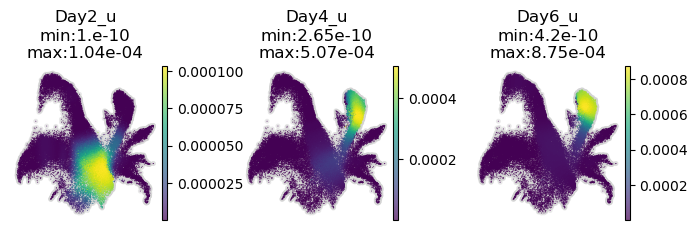

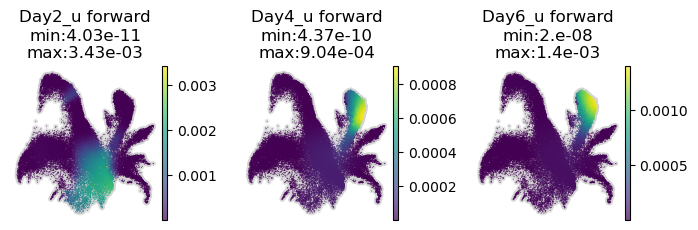

In [ ]:
if "u" in dir(pde_model):
    u_pred_b = np.concatenate(u_pred_ls, axis=0).reshape(n_timepoint,-1)
    fig1, axs1 = PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
    fig2, axs2 = PINN.pl.params_in_umap(t7_ad, u_pred_b, param='u forward', cell_of_t=False);

g saved to  results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_g.npy
prediction of shape (3, 47907)
D saved to  results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_D.npy
prediction of shape (3, 47907)
prediction of shape (3, 47907)
prediction of shape (3, 47907)


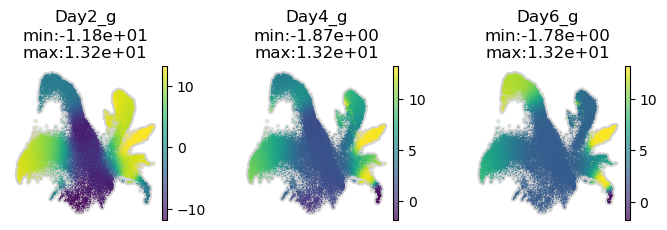

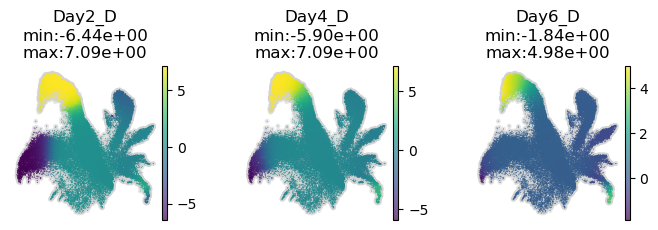

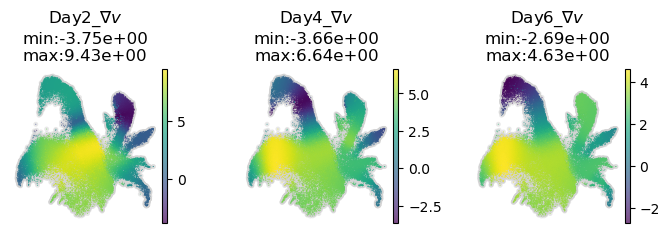

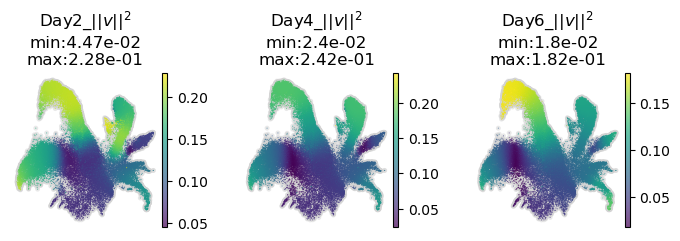

In [ ]:
v_pred_ay = np.concatenate(v_ls, axis=0).reshape(n_timepoint, -1, n_dimension)
g_pred_ay = np.concatenate(g_ls, axis=0).reshape(n_timepoint,-1)
D_pred_ay = np.concatenate(D_ls, axis=0).reshape(n_timepoint,-1)
    

for param in ['g', 'D']:
    param_pred = locals()[f'{param}_pred_ay']
    npy_savepath = f"{result_dir}/{result_base}_{param}.npy"
    np.save(npy_savepath, param_pred)
    print(param, 'saved to ', npy_savepath)
    fig_param, axs_param = PINN.pl.params_in_umap(t7_ad, param_pred, param=param, cell_of_t=False);
    #save

    fig_param.savefig(f'{plot_save}/{param}.png', transparent=True, bbox_inches='tight', dpi=200)

nabla_v = pde_model.predict_param(DS_t7, param='v');
fig_v1, axs_v = PINN.pl.params_in_umap(t7_ad, nabla_v, param=r'$\nabla v$', cell_of_t=False);


v_norm = v_pred_ay / DM_range[None,None,:]
v_norm2 = np.sqrt(np.power(v_norm,2).mean(axis=2))
fig_v2, axs_v = PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=False);

np.save(f"{result_dir}/{result_base}_v.npy", v_pred_ay)
np.save(f"{result_dir}/{result_base}_v_norm.npy", v_norm2)

100%|██████████| 288/288 [00:00<00:00, 1164.74it/s]


prediction of shape (3, 47907)
prediction of shape (3, 47907)
g saved to  results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_g.npy
prediction of shape (3, 47907)
D saved to  results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_D.npy
prediction of shape (3, 47907)
prediction of shape (3, 47907)
prediction of shape (3, 47907)


ValueError: Value passed for key 'Day2 v' is of incorrect shape. Values of layers must match dimensions ('obs', 'var') of parent. Value had shape (47907, 5) while it should have had (7256, 5).

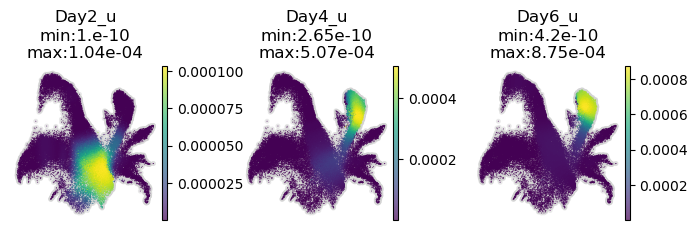

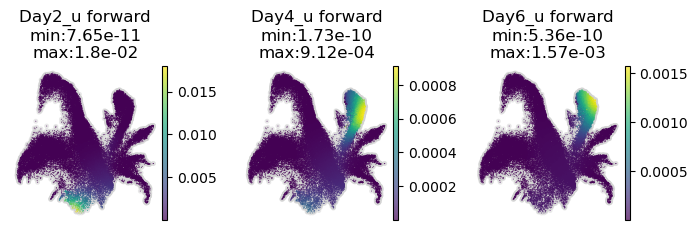

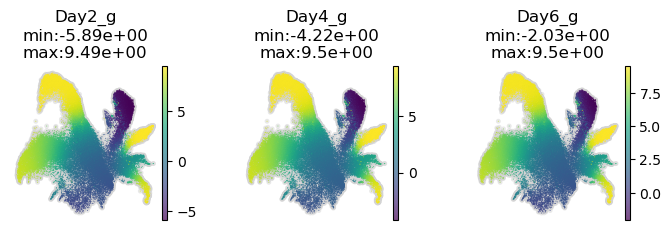

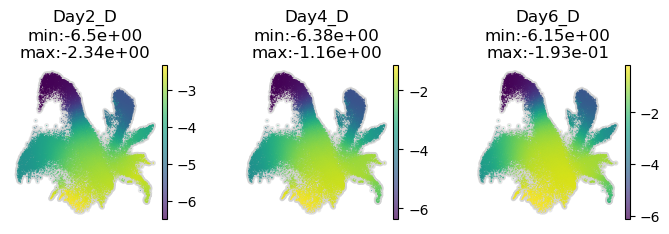

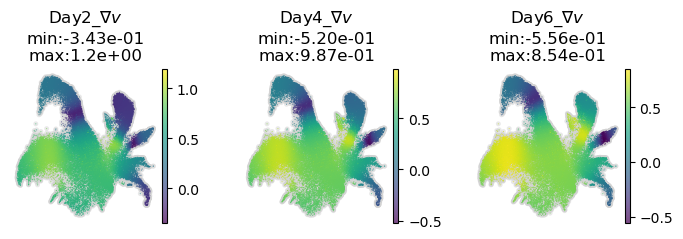

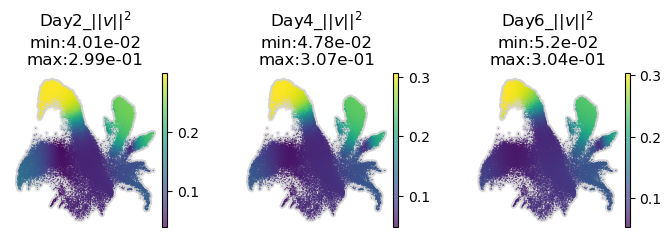

In [ ]:
# %load_ext autoreload
# %autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/home/wergillius/Project/PINN_dynamics")


# ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=53-total_loss=0.21702482.ckpt"
ckpt_path = "logs/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=191-total_loss=3.19271231.ckpt"
# if __name__ == '__main__':
#     ckpt_path = sys.argv[1]

# CHANG THIS !!!!!
n_dimension = 5
ct_key = 'label_man'


date = time.strftime("%b%d")
result_dir = "results/" + "/".join(ckpt_path.split("/")[1:3]) + f"_{date}"
result_base = re.match(r".*/(version_\d{1,2})/.*", ckpt_path).group(1)

if not os.path.exists(result_dir):
    try:
        os.mkdir(result_dir)
    except:
        os.mkdir(os.path.dirname(result_dir))
        os.mkdir(result_dir)

plot_save = f'{result_dir}/{result_base}_plot'
if not os.path.exists(plot_save):
    os.mkdir(plot_save)


# load model
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])


full_adata = sc.read_h5ad(f"data/klein_subset.h5ad")
base_cellstate = full_adata.obsm[cellstate_key][:,:n_dimension].copy()

# the DS
DS_t7 = reader.TwoTimpepoint_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              base_cellstate = base_cellstate,
                              batchsize = 300
                              )

# adata
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)
cellstate = torch.from_numpy(DS_t7.cellstate).float()

if cellstate.shape[0] > t7_ad.shape[0]:
    t7_ad = full_adata

DM_range = (cellstate.max(axis=0).values - cellstate.min(axis=0).values).cpu().numpy()

# FORWARD 
u_pred_ls = []
v_ls = []
D_ls = []
g_ls = []
chunk_size= 500

s_ts = DS_t7.s.float().to(device)
t_ts = DS_t7.t_b.float().to(device)

with torch.no_grad():
    for i in tqdm(range(0, len(t_ts), chunk_size)):                              
        s_in = s_ts[i:i+chunk_size]
        t_in = t_ts[i:i+chunk_size]

        v_pred = pde_model.v(s_in, t_in)
        g_pred = pde_model.g(s_in, t_in)
        D_pred = pde_model.D(s_in, t_in)
        
        v_ls.append(v_pred.detach().cpu().numpy())
        g_ls.append(g_pred.detach().cpu().numpy())
        D_ls.append(D_pred.detach().cpu().numpy())

        if "u" in dir(pde_model):
            u_pred = torch.exp(pde_model.u(s_in, t_in))
            u_pred_ls.append(u_pred.detach().cpu().numpy())

if "u" in dir(pde_model):
    u_pred_b = np.concatenate(u_pred_ls, axis=0).reshape(n_timepoint,-1)
    fig1, axs1 = PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
    fig2, axs2 = PINN.pl.params_in_umap(t7_ad, u_pred_b, param='u forward', cell_of_t=False);

    
# # other params

v_pred_ay = np.concatenate(v_ls, axis=0).reshape(n_timepoint, -1, n_dimension)
g_pred_ay = np.concatenate(g_ls, axis=0).reshape(n_timepoint,-1)
D_pred_ay = np.concatenate(D_ls, axis=0).reshape(n_timepoint,-1)
    

for param in ['g', 'D']:
    param_pred = locals()[f'{param}_pred_ay']
    npy_savepath = f"{result_dir}/{result_base}_{param}.npy"
    np.save(npy_savepath, param_pred)
    print(param, 'saved to ', npy_savepath)
    fig_param, axs_param = PINN.pl.params_in_umap(t7_ad, param_pred, param=param, cell_of_t=False);
    #save

    fig_param.savefig(f'{plot_save}/{param}.png', transparent=True, bbox_inches='tight', dpi=200)

nabla_v = pde_model.predict_param(DS_t7, param='v');
fig_v1, axs_v = PINN.pl.params_in_umap(t7_ad, nabla_v, param=r'$\nabla v$', cell_of_t=False);


v_norm = v_pred_ay / DM_range[None,None,:]
v_norm2 = np.sqrt(np.power(v_norm,2).mean(axis=2))
fig_v2, axs_v = PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=False);

np.save(f"{result_dir}/{result_base}_v.npy", v_pred_ay)
np.save(f"{result_dir}/{result_base}_v_norm.npy", v_norm2)
# PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=True);


# v_stream plot

## generate adata base on cellsate coords
import scvelo as scv
cellstate_ad = PINN.tl.make_coord_adata(adata, cellstate_key=cellstate_key, v = v_pred_ay)
vkeys = [k for k in list(cellstate_ad.layers.keys()) if k.endswith("v")]
sc.pp.neighbors(cellstate_ad, n_neighbors=15)


for vkey in vkeys:

    # compute velocity graph
    scv.tl.velocity_graph(cellstate_ad, vkey=vkey, xkey='cellstate', n_jobs=20)

    # vis
    fig_velocity = plt.figure(dpi=100, figsize=(4,4))
    ax = fig_velocity.gca()
    scv.pl.velocity_embedding_stream(cellstate_ad, color=ct_key, vkey=vkey, 
                                     basis='umap', ax=ax, 
                                     legend_loc='right', alpha=0.01,
                                     title=vkey, 
                                     save=f"{plot_save}/{vkey}.png")

#
# predict u with ode integrat


u_int_all = [u_b[0]]
chunk_size= 500
t_list = timepoints / 10
it = 0
for t0, t1 in tqdm(zip(t_list[:-1], t_list[1:])):

    u_t_ls = []

    for i in range(0, len(cellstate), chunk_size):

        s0 = cellstate[i:i+chunk_size].to(device).requires_grad_()
        tompos_u0 = torch.from_numpy(u_b[it, i:i+chunk_size]).float().to(device).requires_grad_()
        init_condition = (tompos_u0, s0)

        step_size = np.around((t1 - t0)/15, decimals=1).item() 
        step_size = step_size if step_size > 0 else 0.05
        step_size = min(step_size, 0.4)

        u_t, s_t = odeint(
                        pde_model,
                        y0 = init_condition,
                        t = torch.tensor([t0, t1]).type(torch.float32).to(device),
                        atol=1e-4,
                        rtol=1e-4,
                        method='dopri5',
                        adjoint_options={'norm':'seminorm'},
                    )

        torch.cuda.empty_cache()

        u_int = torch.nn.functional.relu(u_t[-1])
        u_t_ls.append(u_int.detach().cpu().numpy())
        del u_t, s_t
        torch.cuda.empty_cache()

    u_int = np.concatenate(u_t_ls)
    
    u_int_all.append(u_int)
    it+=1

u_int_all = np.stack(u_int_all)

print(u_b.sum(axis=1))
print(u_int_all.sum(axis=1))

fig_obs, axs = PINN.pl.params_in_umap(t7_ad, u_b, param='u b', cell_of_t=True);
fig_int1, axs = PINN.pl.params_in_umap(t7_ad, u_int_all, param='u by integrat', cell_of_t=True);
fig_int2, axs = PINN.pl.params_in_umap(t7_ad, u_int_all, timepoints=timepoints, param='u by integrat', cell_of_t=False);

# add the density into obs
for i, d in enumerate(timepoints):
    t7_ad.obs[f'u_int_{d}'] = u_int_all[i]
    t7_ad.obs[f'u_obs_{d}'] = u_b[i]

    t7_ad.obs[f'p_int_{d}'] = u_int_all[i] / u_int_all[i].sum()
    t7_ad.obs[f'p_obs_{d}'] = u_b[i] / u_b[i].sum()

gflow, vflow, dflow = pde_model.statify_flow(DS_t7)
stratified_flow = {
    "dilution flow" : gflow,
    'drift flow' : vflow,
    'diffuse flow' : dflow
}

flow_keys = []
for key, flow in stratified_flow.items():
    for i, d in enumerate(timepoints[1:]):
        t7_ad.obs[f'Day{d} {key}'] = flow[i]
        flow_keys.append(f'Day{d} {key}')
    # visualize
    fig_flow, axs = PINN.pl.params_in_umap(t7_ad, flow, timepoints=timepoints[1:], param=key, cell_of_t=False);
    fig_flow.savefig(f'{plot_save}/{key}.png', transparent=True, bbox_inches='tight', dpi=200)

# flow by cell type
cm_celltype = dict(zip(t7_ad.obs[ct_key].cat.categories ,t7_ad.uns[f'{ct_key}_colors']))

for i, d in enumerate(timepoints[1:]):

    # stratified
    flow_key_obs = t7_ad.obs.groupby(ct_key).agg({f'Day{d} {key}':'sum' for key in stratified_flow})
    flow_melt_obs = flow_key_obs.reset_index().melt(id_vars=ct_key, var_name='flow')

    g1 = sns.catplot(data = flow_melt_obs, y = ct_key, hue=ct_key, x = 'value', col='flow', kind='bar', sharex=False, palette=cm_celltype)
    g1.savefig(f'{plot_save}/Day{d}_stratify_flow.png', transparent=True, bbox_inches='tight', dpi=200)

    # stratified flow fold chanage
    density_change = t7_ad.obs[f'u_int_{d}'].values - t7_ad.obs[f'u_int_{timepoints[i]}'].values
    t7_ad.obs[f'Day{d} u change'] = density_change

    agg_change = t7_ad.obs.groupby(ct_key).agg({f'Day{d} u change':'sum'}).values
    flow_fc_obs = flow_key_obs / agg_change
    flow_melt_fc = flow_fc_obs.reset_index().melt(id_vars=ct_key, var_name='flow')

    g2 = sns.catplot(data = flow_melt_fc, y = ct_key, hue=ct_key, x = 'value', col='flow', kind='bar', sharex=False, palette=cm_celltype)
    g2.savefig(f'{plot_save}/Day{d}_contrib.png', transparent=True, bbox_inches='tight', dpi=200)


    norm_u = t7_ad.obs.groupby(ct_key).agg({f'u_int_{d}':'sum'}).values
    flow_key_norm = flow_key_obs / norm_u
    flow_melt_norm = flow_key_norm.reset_index().melt(id_vars=ct_key, var_name='flow')

    g3 = sns.catplot(data = flow_melt_norm, y = ct_key, hue=ct_key, x = 'value', col='flow', kind='bar', sharex=False, palette=cm_celltype)
    g3.savefig(f'{plot_save}/Day{d}_stratify_flow_norm.png', transparent=True, bbox_inches='tight', dpi=200)



obs = t7_ad.obs.copy()

proint_columns = ['p_int_%s'%t for t in timepoints] 
probs_columns =['p_obs_%s'%t for t in timepoints] 
# density by cell type

p_by_celltype = obs[probs_columns+proint_columns+[ct_key]].groupby(ct_key).agg("sum")
p_celltype_melt = pd.melt(p_by_celltype.reset_index(), id_vars=[ct_key])
p_celltype_melt['data'] = p_celltype_melt['variable'].str.extract(r"p_(\w{3})_\d")
p_celltype_melt['time'] = p_celltype_melt['variable'].str.extract(r"p_\w{3}_(\d*)")

plt.figure(figsize=(9, 3), dpi=300)
ax=PINN.pl.stack_catplot(x='time', y='value', cat='data', stack=ct_key, data=p_celltype_melt , palette=cm_celltype)
ax.set_xlabel("time")
ax.set_ylabel("cell type proportion")

fig_subplot, axs = plt.subplots(1, n_timepoint, figsize=(3*n_timepoint, 6), dpi=300, sharey=True)
for i, t in enumerate(timepoints):
    t = str(t)
    ax=axs[i]

    sns.barplot(data=p_celltype_melt.query("`time` == @t"), 
                # color=ct_key, #palette=cm_celltype,
                edgecolor='gray', width=0.7,
                x = 'value', y=ct_key, hue='data', ax=ax)
    
    for bars, hatch, legend_handle in zip(ax.containers, ['', '//'], ax.legend_.legendHandles):
        for bar, color in zip(bars, cm_celltype.values()):
            alpha = 1 if hatch == '' else 0.5
            bar.set_alpha(alpha)
            bar.set_facecolor(color)
            bar.set_hatch(hatch)
        # update the existing legend, use twice the hatching pattern to make it denser
        legend_handle.set_hatch(hatch + hatch)

    sns.despine()
    axs[i].set_xlabel("")
    if i!=0:
        axs[i].legend([], frameon=False)

axs[0].set_ylabel("")
axs[1].set_xlabel("cell type proportion")


def savefig(fig, name):
    fig.savefig(f'{plot_save}/{name}.png', transparent=True, bbox_inches='tight', dpi=200)


if "u" in dir(pde_model):
    savefig(fig1, "observed_density")
    savefig(fig2, "forward_pred_density")

savefig(fig_v1, "nabla_v")
savefig(fig_v2, "v_norm")
savefig(fig_subplot, "celltype_proportion")
savefig(fig_int2, 'simulation')

computing velocity graph (using 20/48 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:13) --> added 
    'Day2 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:07) --> added
    'Day2 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_plot/Day2 v.png


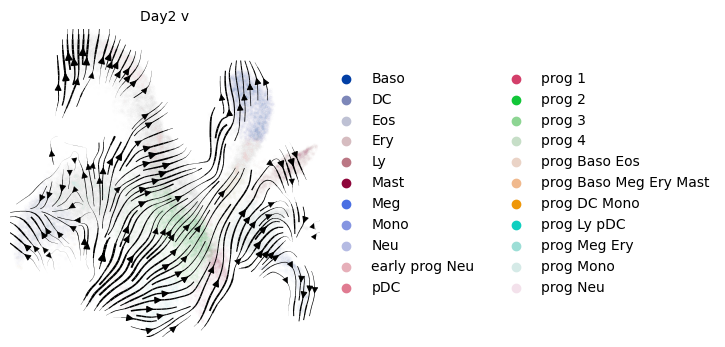

computing velocity graph (using 20/48 cores)
    finished (0:00:06) --> added 
    'Day4 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:07) --> added
    'Day4 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_plot/Day4 v.png


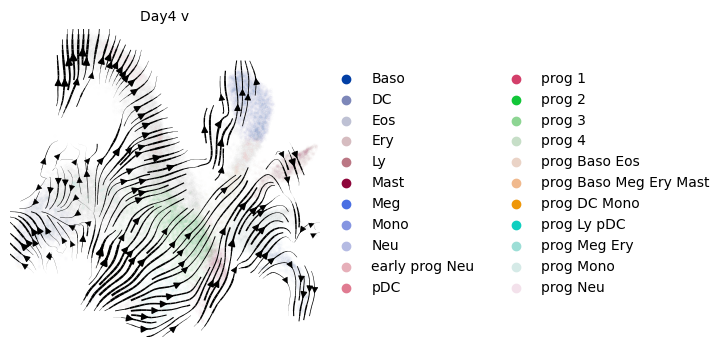

computing velocity graph (using 20/48 cores)
    finished (0:00:07) --> added 
    'Day6 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:07) --> added
    'Day6 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_plot/Day6 v.png


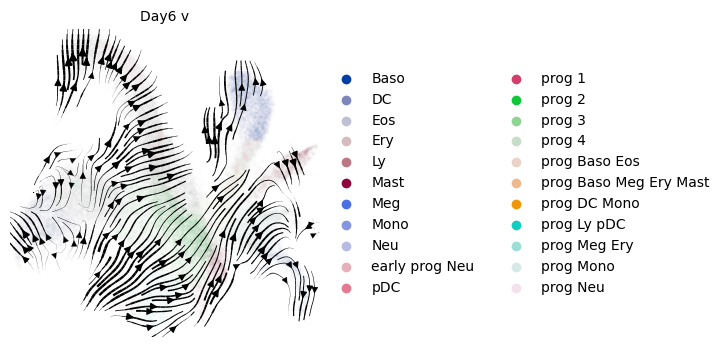

In [ ]:
cellstate_ad = PINN.tl.make_coord_adata(t7_ad, cellstate_key=cellstate_key, v = v_pred_ay)
vkeys = [k for k in list(cellstate_ad.layers.keys()) if k.endswith("v")]
sc.pp.neighbors(cellstate_ad, n_neighbors=15)


for vkey in vkeys:

    # compute velocity graph
    scv.tl.velocity_graph(cellstate_ad, vkey=vkey, xkey='cellstate', n_jobs=20)

    # vis
    fig_velocity = plt.figure(dpi=100, figsize=(4,4))
    ax = fig_velocity.gca()
    scv.pl.velocity_embedding_stream(cellstate_ad, color=ct_key, vkey=vkey, 
                                     basis='umap', ax=ax, 
                                     legend_loc='right', alpha=0.01,
                                     title=vkey, 
                                     save=f"{plot_save}/{vkey}.png")

100%|██████████| 288/288 [00:06<00:00, 45.83it/s]


prediction of shape (3, 47907)
prediction of shape (3, 47907)
g saved to  results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_5_g.npy
prediction of shape (3, 47907)
D saved to  results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_5_D.npy
prediction of shape (3, 47907)
prediction of shape (3, 47907)
prediction of shape (3, 47907)
computing velocity graph (using 20/48 cores)
    finished (0:00:53) --> added 
    'Day2 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:08) --> added
    'Day2 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_5_plot/Day2 v.png


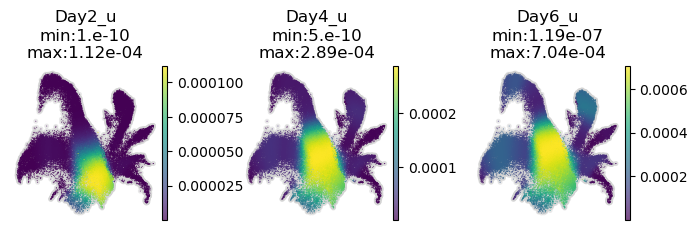

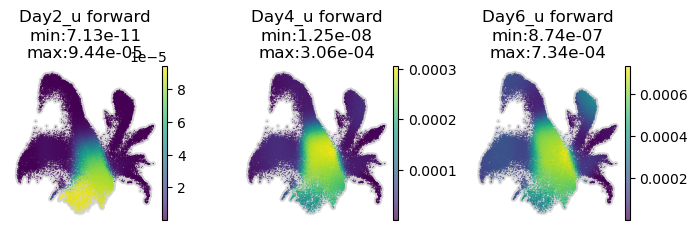

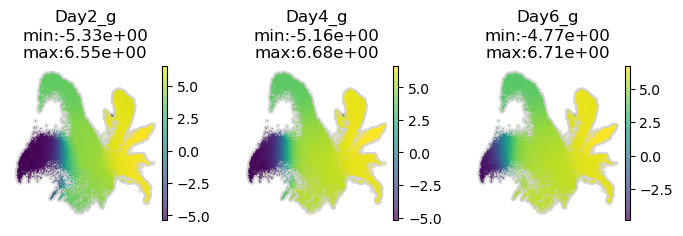

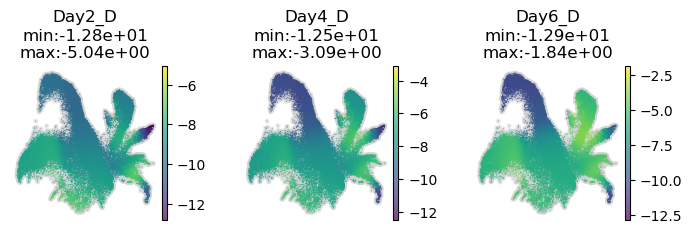

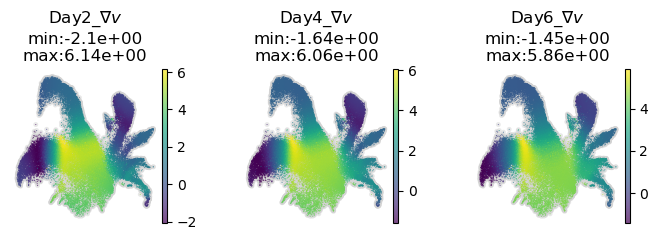

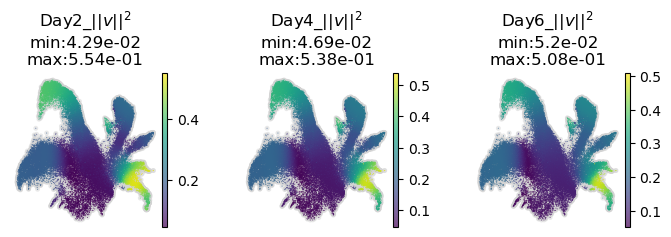

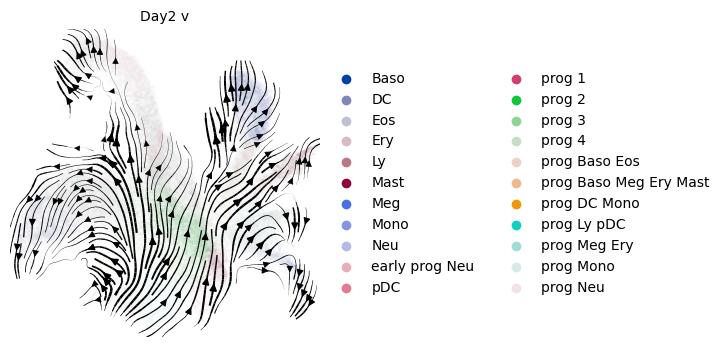

computing velocity graph (using 20/48 cores)
    finished (0:00:07) --> added 
    'Day4 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:08) --> added
    'Day4 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_5_plot/Day4 v.png


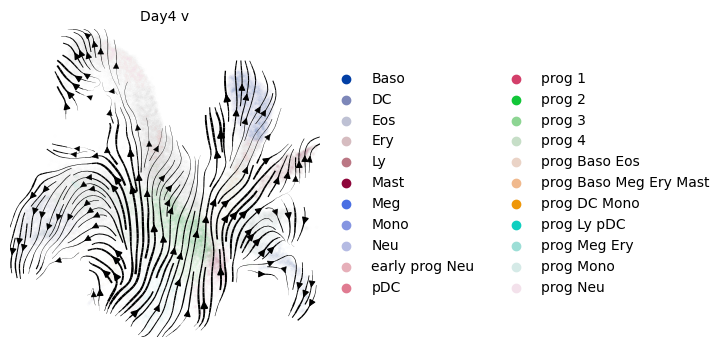

computing velocity graph (using 20/48 cores)
    finished (0:00:07) --> added 
    'Day6 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:07) --> added
    'Day6 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_5_plot/Day6 v.png


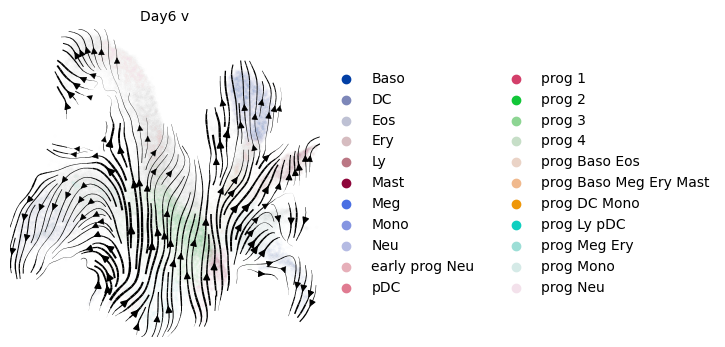

2it [00:07,  3.58s/it]


[ 1.0000002  5.        15.       ]
[ 1.0000002  4.961025  14.982686 ]
prediction of shape (3, 47907)
prediction of shape (3, 47907)
prediction of shape (3, 47907)
prediction of shape (2, 47907)
prediction of shape (2, 47907)
prediction of shape (2, 47907)
finished


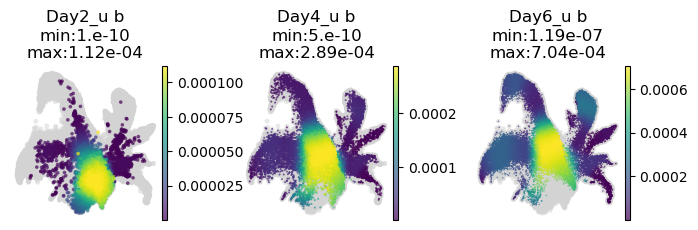

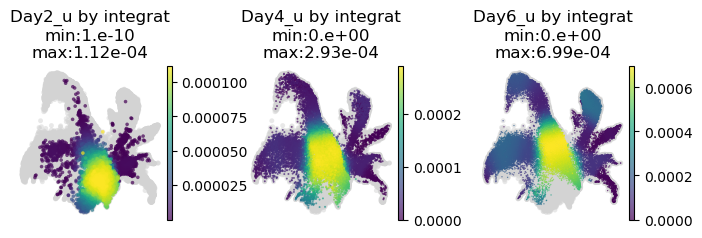

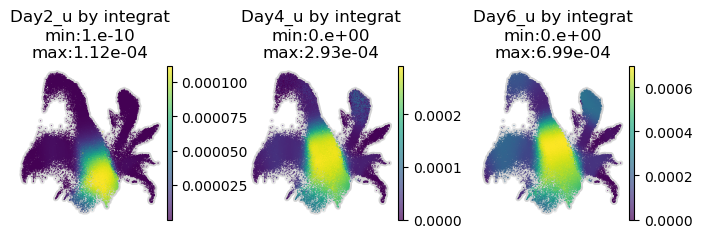

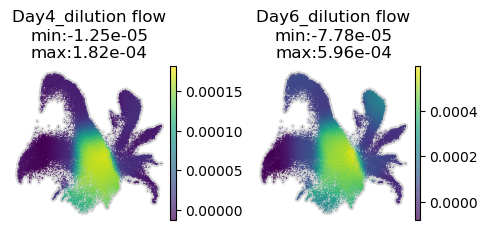

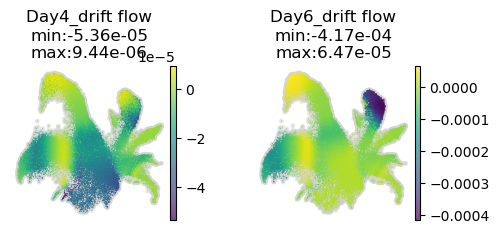

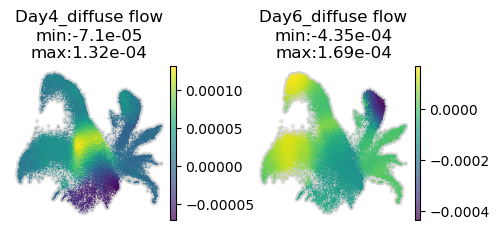

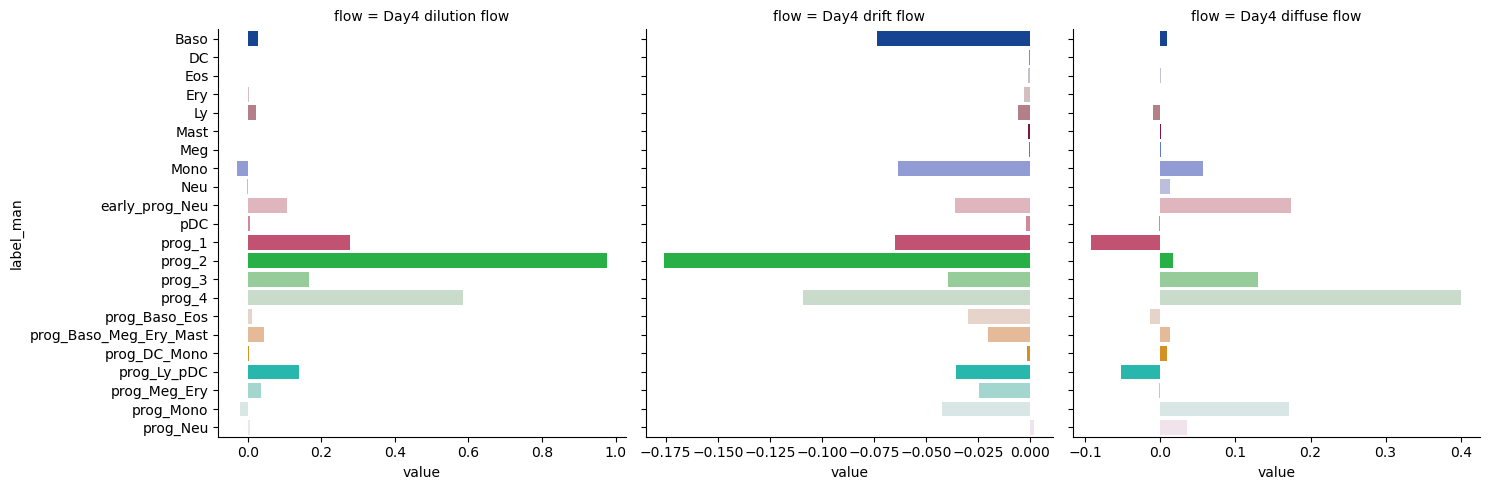

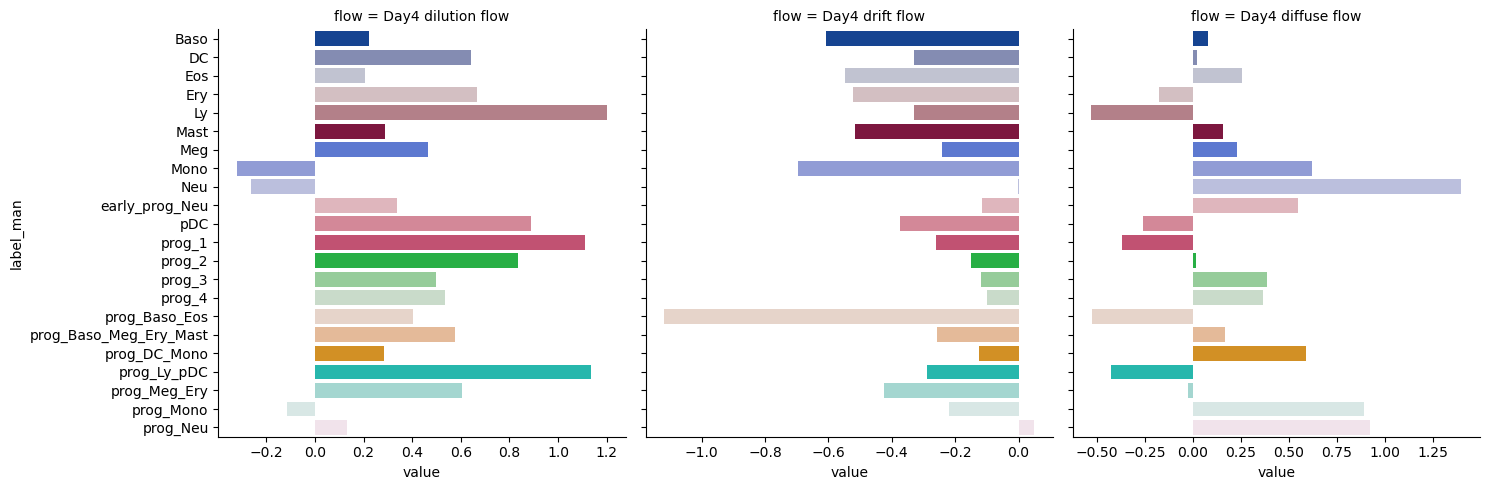

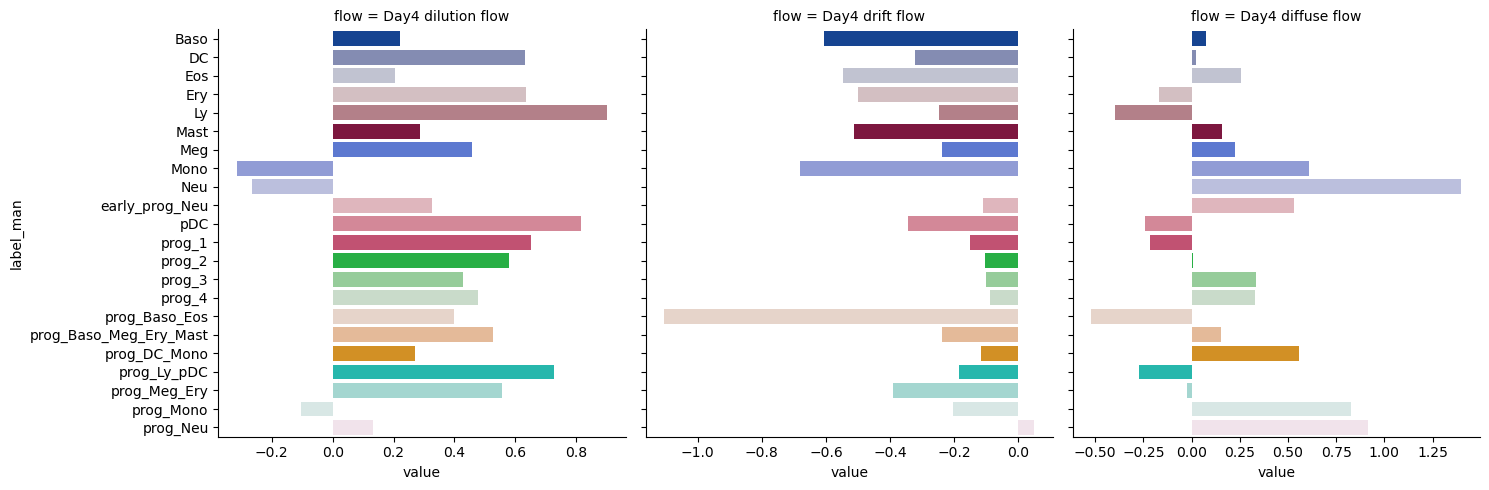

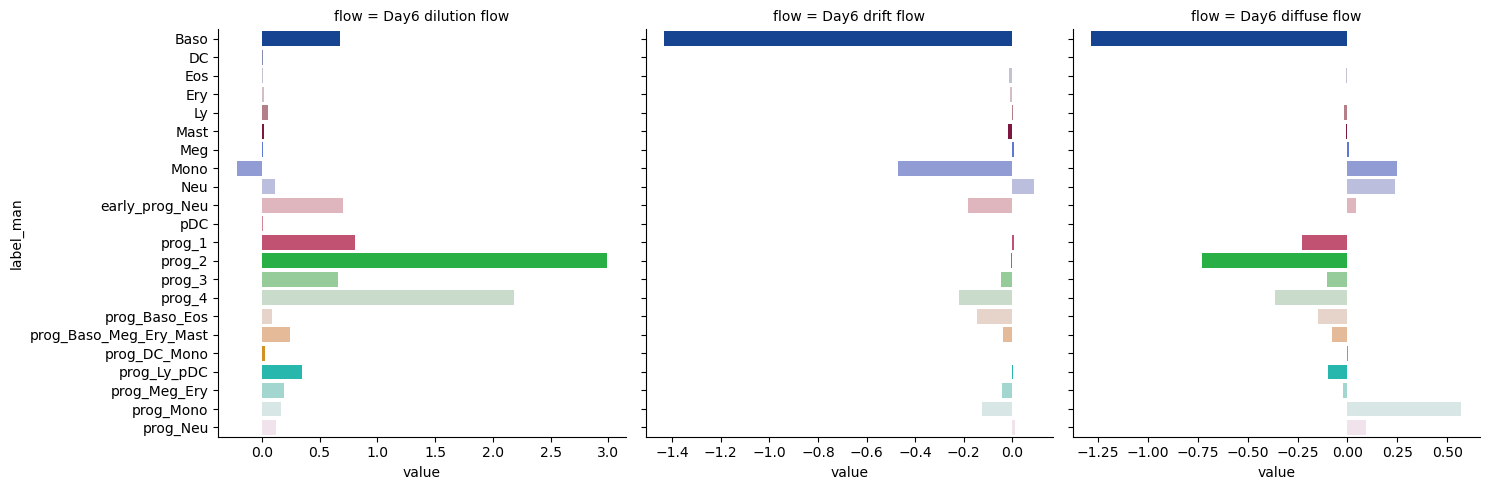

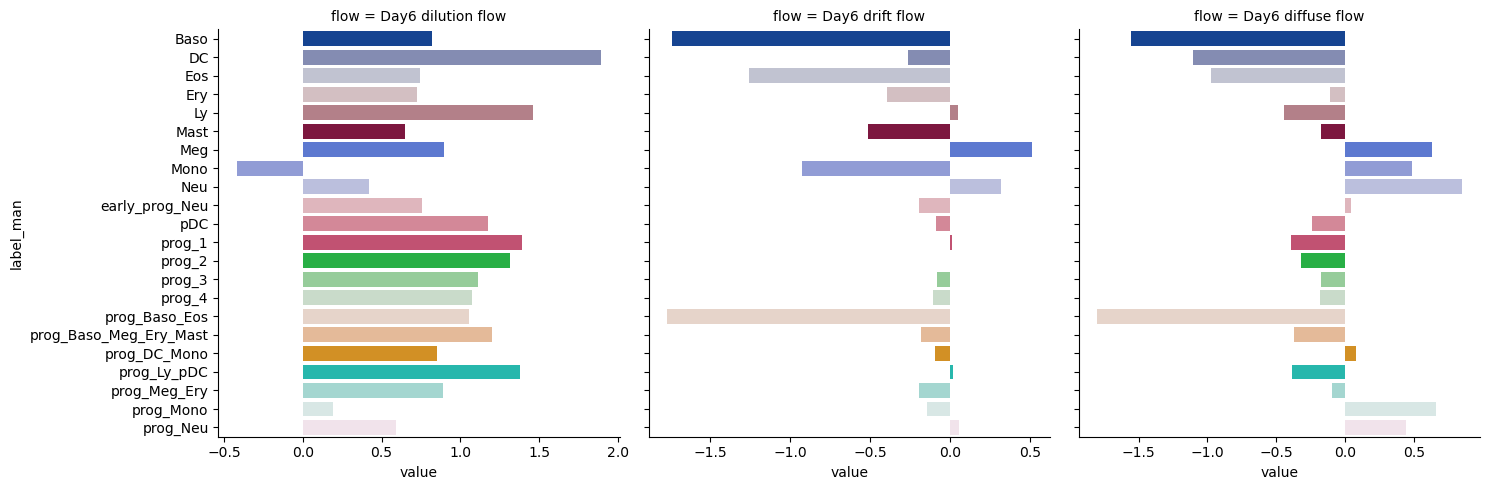

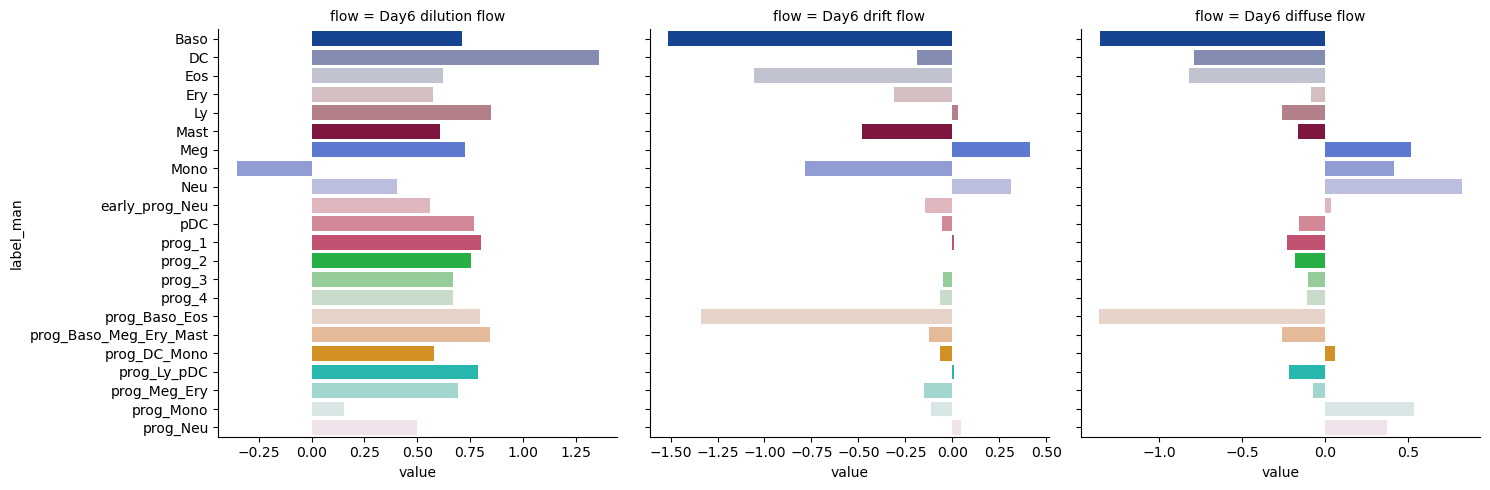

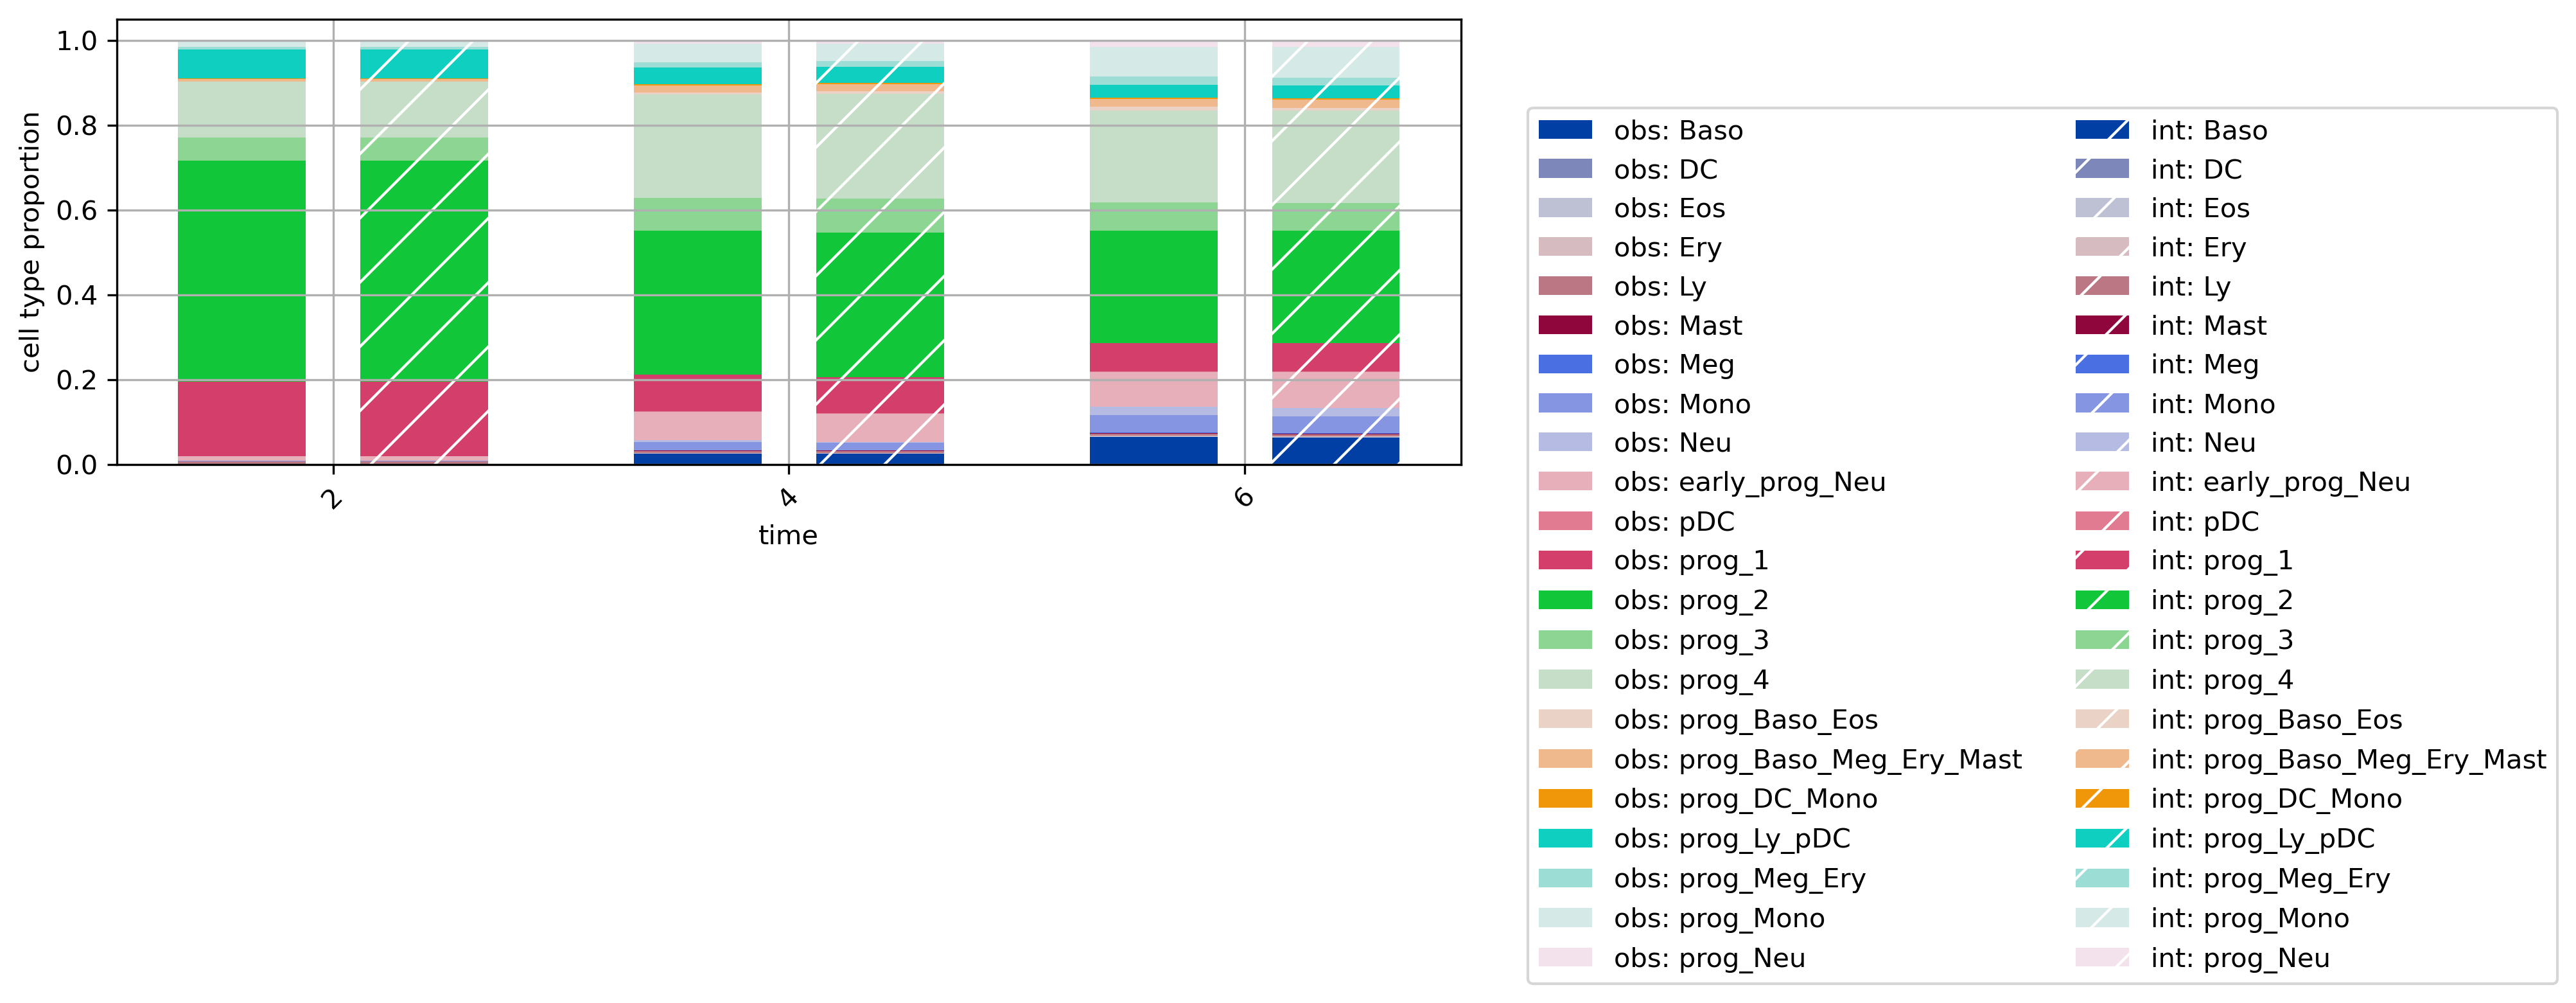

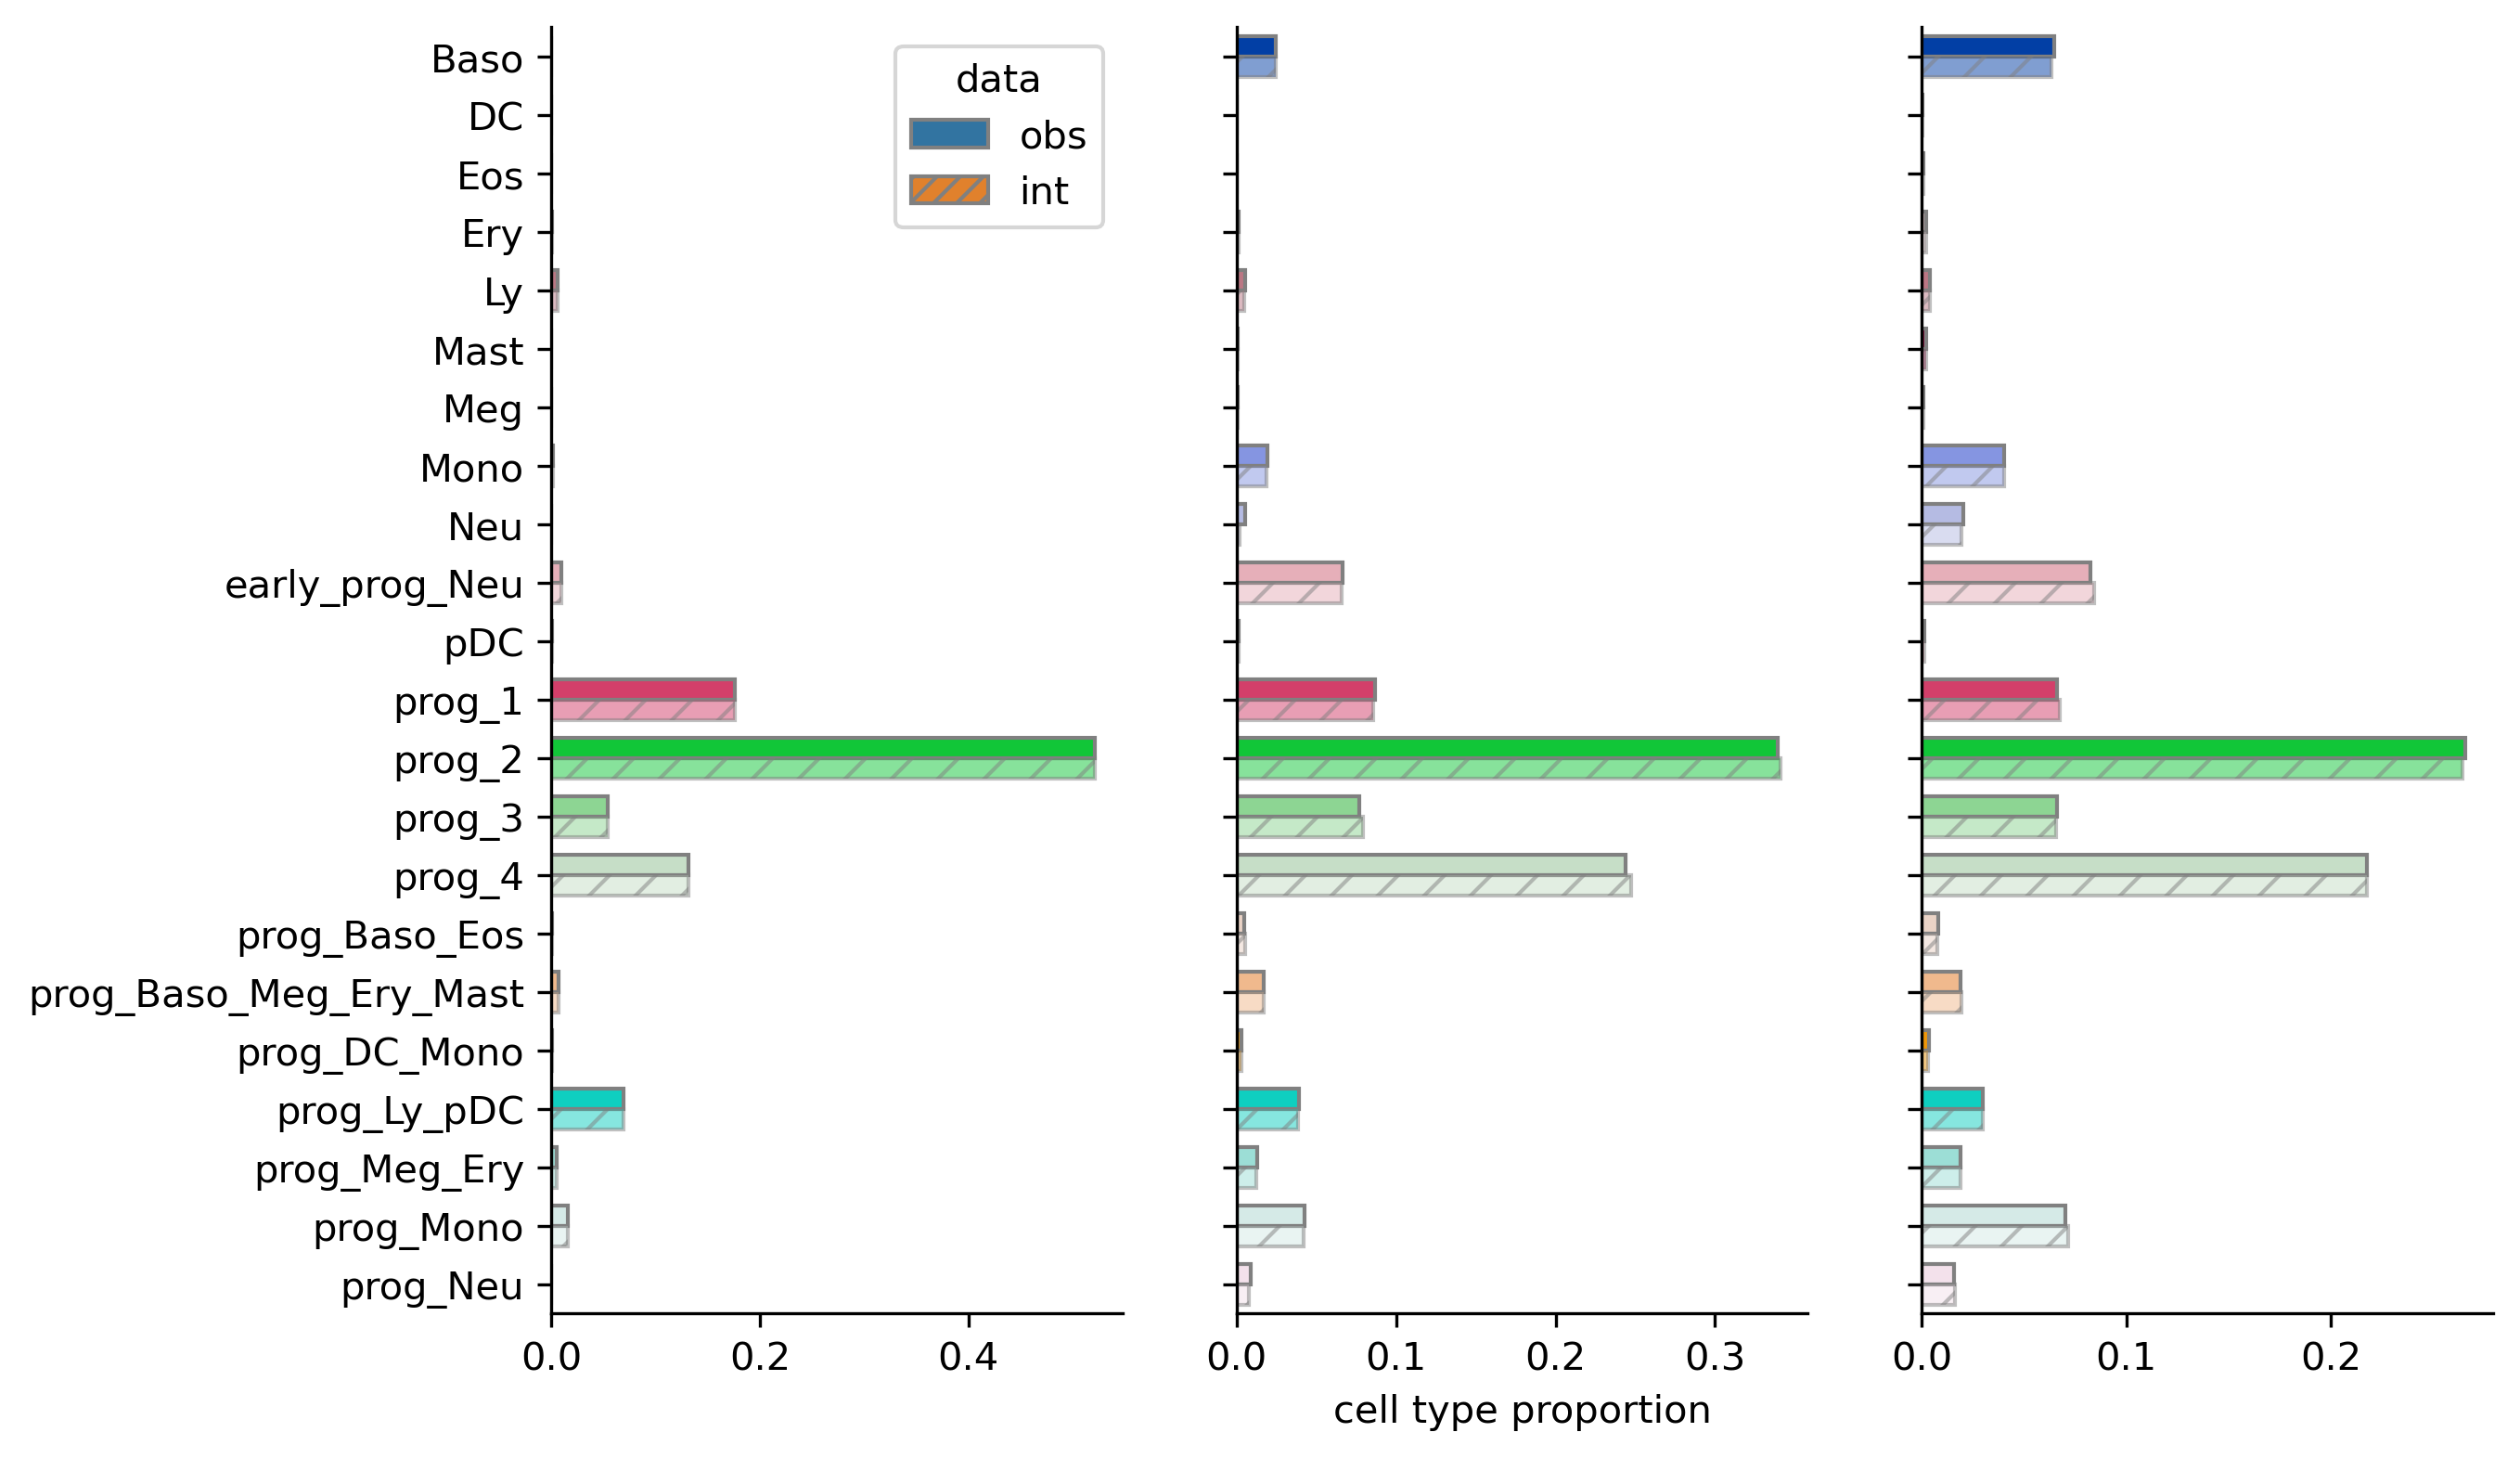

In [ ]:
# %load_ext autoreload
# %autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/home/wergillius/Project/PINN_dynamics")


ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_5/checkpoints/epoch=17-total_loss=0.31139943.ckpt"
# ckpt_path = "logs/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=191-total_loss=3.19271231.ckpt"
# if __name__ == '__main__':
#     ckpt_path = sys.argv[1]

# CHANG THIS !!!!!
n_dimension = 5
ct_key = 'label_man'


date = time.strftime("%b%d")
result_dir = "results/" + "/".join(ckpt_path.split("/")[1:3]) + f"_{date}"
result_base = re.match(r".*/(version_\d{1,2})/.*", ckpt_path).group(1)

if not os.path.exists(result_dir):
    try:
        os.mkdir(result_dir)
    except:
        os.mkdir(os.path.dirname(result_dir))
        os.mkdir(result_dir)

plot_save = f'{result_dir}/{result_base}_plot'
if not os.path.exists(plot_save):
    os.mkdir(plot_save)


# load model
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])


full_adata = sc.read_h5ad(f"data/klein_subset.h5ad")
base_cellstate = full_adata.obsm[cellstate_key][:,:n_dimension].copy()

# the DS
DS_t7 = reader.TwoTimpepoint_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              base_cellstate = None,
                              batchsize = 300
                              )

# adata
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)
cellstate = torch.from_numpy(DS_t7.cellstate).float()

if cellstate.shape[0] > t7_ad.shape[0]:
    t7_ad = full_adata

DM_range = (cellstate.max(axis=0).values - cellstate.min(axis=0).values).cpu().numpy()

# FORWARD 
u_pred_ls = []
v_ls = []
D_ls = []
g_ls = []
chunk_size= 500

s_ts = DS_t7.s.float().to(device)
t_ts = DS_t7.t_b.float().to(device)

with torch.no_grad():
    for i in tqdm(range(0, len(t_ts), chunk_size)):                              
        s_in = s_ts[i:i+chunk_size]
        t_in = t_ts[i:i+chunk_size]

        v_pred = pde_model.v(s_in, t_in)
        g_pred = pde_model.g(s_in, t_in)
        D_pred = pde_model.D(s_in, t_in)
        
        v_ls.append(v_pred.detach().cpu().numpy())
        g_ls.append(g_pred.detach().cpu().numpy())
        D_ls.append(D_pred.detach().cpu().numpy())

        if "u" in dir(pde_model):
            u_pred = torch.exp(pde_model.u(s_in, t_in))
            u_pred_ls.append(u_pred.detach().cpu().numpy())

if "u" in dir(pde_model):
    u_pred_b = np.concatenate(u_pred_ls, axis=0).reshape(n_timepoint,-1)
    fig1, axs1 = PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
    fig2, axs2 = PINN.pl.params_in_umap(t7_ad, u_pred_b, param='u forward', cell_of_t=False);

    
# # other params

v_pred_ay = np.concatenate(v_ls, axis=0).reshape(n_timepoint, -1, n_dimension)
g_pred_ay = np.concatenate(g_ls, axis=0).reshape(n_timepoint,-1)
D_pred_ay = np.concatenate(D_ls, axis=0).reshape(n_timepoint,-1)
    

for param in ['g', 'D']:
    param_pred = locals()[f'{param}_pred_ay']
    npy_savepath = f"{result_dir}/{result_base}_{param}.npy"
    np.save(npy_savepath, param_pred)
    print(param, 'saved to ', npy_savepath)
    fig_param, axs_param = PINN.pl.params_in_umap(t7_ad, param_pred, param=param, cell_of_t=False);
    #save

    fig_param.savefig(f'{plot_save}/{param}.png', transparent=True, bbox_inches='tight', dpi=200)

nabla_v = pde_model.predict_param(DS_t7, param='v');
fig_v1, axs_v = PINN.pl.params_in_umap(t7_ad, nabla_v, param=r'$\nabla v$', cell_of_t=False);


v_norm = v_pred_ay / DM_range[None,None,:]
v_norm2 = np.sqrt(np.power(v_norm,2).mean(axis=2))
fig_v2, axs_v = PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=False);

np.save(f"{result_dir}/{result_base}_v.npy", v_pred_ay)
np.save(f"{result_dir}/{result_base}_v_norm.npy", v_norm2)
# PINN.pl.params_in_umap(t7_ad, v_norm2, param=r'$||v||^2$', cell_of_t=True);


# v_stream plot

## generate adata base on cellsate coords
import scvelo as scv
cellstate_ad = PINN.tl.make_coord_adata(t7_ad, cellstate_key=cellstate_key, v = v_pred_ay)
vkeys = [k for k in list(cellstate_ad.layers.keys()) if k.endswith("v")]
sc.pp.neighbors(cellstate_ad, n_neighbors=15)


for vkey in vkeys:

    # compute velocity graph
    scv.tl.velocity_graph(cellstate_ad, vkey=vkey, xkey='cellstate', n_jobs=20)

    # vis
    fig_velocity = plt.figure(dpi=100, figsize=(4,4))
    ax = fig_velocity.gca()
    scv.pl.velocity_embedding_stream(cellstate_ad, color=ct_key, vkey=vkey, 
                                     basis='umap', ax=ax, 
                                     legend_loc='right', alpha=0.01,
                                     title=vkey, 
                                     save=f"{plot_save}/{vkey}.png")

#
# predict u with ode integrat


u_int_all = [u_b[0]]
chunk_size= 500
t_list = timepoints / 10
it = 0
for t0, t1 in tqdm(zip(t_list[:-1], t_list[1:])):

    u_t_ls = []

    for i in range(0, len(cellstate), chunk_size):

        s0 = cellstate[i:i+chunk_size].to(device).requires_grad_()
        tompos_u0 = torch.from_numpy(u_b[it, i:i+chunk_size]).float().to(device).requires_grad_()
        init_condition = (tompos_u0, s0)

        step_size = np.around((t1 - t0)/15, decimals=1).item() 
        step_size = step_size if step_size > 0 else 0.05
        step_size = min(step_size, 0.4)

        u_t, s_t = odeint(
                        pde_model,
                        y0 = init_condition,
                        t = torch.tensor([t0, t1]).type(torch.float32).to(device),
                        atol=1e-4,
                        rtol=1e-4,
                        method='dopri5',
                        adjoint_options={'norm':'seminorm'},
                    )

        torch.cuda.empty_cache()

        u_int = torch.nn.functional.relu(u_t[-1])
        u_t_ls.append(u_int.detach().cpu().numpy())
        del u_t, s_t
        torch.cuda.empty_cache()

    u_int = np.concatenate(u_t_ls)
    
    u_int_all.append(u_int)
    it+=1

u_int_all = np.stack(u_int_all)

print(u_b.sum(axis=1))
print(u_int_all.sum(axis=1))

fig_obs, axs = PINN.pl.params_in_umap(t7_ad, u_b, param='u b', cell_of_t=True);
fig_int1, axs = PINN.pl.params_in_umap(t7_ad, u_int_all, param='u by integrat', cell_of_t=True);
fig_int2, axs = PINN.pl.params_in_umap(t7_ad, u_int_all, timepoints=timepoints, param='u by integrat', cell_of_t=False);

# add the density into obs
for i, d in enumerate(timepoints):
    t7_ad.obs[f'u_int_{d}'] = u_int_all[i]
    t7_ad.obs[f'u_obs_{d}'] = u_b[i]

    t7_ad.obs[f'p_int_{d}'] = u_int_all[i] / u_int_all[i].sum()
    t7_ad.obs[f'p_obs_{d}'] = u_b[i] / u_b[i].sum()

gflow, vflow, dflow = pde_model.statify_flow(DS_t7)
stratified_flow = {
    "dilution flow" : gflow,
    'drift flow' : vflow,
    'diffuse flow' : dflow
}

flow_keys = []
for key, flow in stratified_flow.items():
    for i, d in enumerate(timepoints[1:]):
        t7_ad.obs[f'Day{d} {key}'] = flow[i]
        flow_keys.append(f'Day{d} {key}')
    # visualize
    fig_flow, axs = PINN.pl.params_in_umap(t7_ad, flow, timepoints=timepoints[1:], param=key, cell_of_t=False);
    fig_flow.savefig(f'{plot_save}/{key}.png', transparent=True, bbox_inches='tight', dpi=200)

# flow by cell type
cm_celltype = dict(zip(t7_ad.obs[ct_key].cat.categories ,t7_ad.uns[f'{ct_key}_colors']))

for i, d in enumerate(timepoints[1:]):

    # stratified
    flow_key_obs = t7_ad.obs.groupby(ct_key).agg({f'Day{d} {key}':'sum' for key in stratified_flow})
    flow_melt_obs = flow_key_obs.reset_index().melt(id_vars=ct_key, var_name='flow')

    g1 = sns.catplot(data = flow_melt_obs, y = ct_key, hue=ct_key, x = 'value', col='flow', kind='bar', sharex=False, palette=cm_celltype)
    g1.savefig(f'{plot_save}/Day{d}_stratify_flow.png', transparent=True, bbox_inches='tight', dpi=200)

    # stratified flow fold chanage
    density_change = t7_ad.obs[f'u_int_{d}'].values - t7_ad.obs[f'u_int_{timepoints[i]}'].values
    t7_ad.obs[f'Day{d} u change'] = density_change

    agg_change = t7_ad.obs.groupby(ct_key).agg({f'Day{d} u change':'sum'}).values
    flow_fc_obs = flow_key_obs / agg_change
    flow_melt_fc = flow_fc_obs.reset_index().melt(id_vars=ct_key, var_name='flow')

    g2 = sns.catplot(data = flow_melt_fc, y = ct_key, hue=ct_key, x = 'value', col='flow', kind='bar', sharex=False, palette=cm_celltype)
    g2.savefig(f'{plot_save}/Day{d}_contrib.png', transparent=True, bbox_inches='tight', dpi=200)


    norm_u = t7_ad.obs.groupby(ct_key).agg({f'u_int_{d}':'sum'}).values
    flow_key_norm = flow_key_obs / norm_u
    flow_melt_norm = flow_key_norm.reset_index().melt(id_vars=ct_key, var_name='flow')

    g3 = sns.catplot(data = flow_melt_norm, y = ct_key, hue=ct_key, x = 'value', col='flow', kind='bar', sharex=False, palette=cm_celltype)
    g3.savefig(f'{plot_save}/Day{d}_stratify_flow_norm.png', transparent=True, bbox_inches='tight', dpi=200)



obs = t7_ad.obs.copy()

proint_columns = ['p_int_%s'%t for t in timepoints] 
probs_columns =['p_obs_%s'%t for t in timepoints] 
# density by cell type

p_by_celltype = obs[probs_columns+proint_columns+[ct_key]].groupby(ct_key).agg("sum")
p_celltype_melt = pd.melt(p_by_celltype.reset_index(), id_vars=[ct_key])
p_celltype_melt['data'] = p_celltype_melt['variable'].str.extract(r"p_(\w{3})_\d")
p_celltype_melt['time'] = p_celltype_melt['variable'].str.extract(r"p_\w{3}_(\d*)")

plt.figure(figsize=(9, 3), dpi=300)
ax=PINN.pl.stack_catplot(x='time', y='value', cat='data', stack=ct_key, data=p_celltype_melt , palette=cm_celltype)
ax.set_xlabel("time")
ax.set_ylabel("cell type proportion")

fig_subplot, axs = plt.subplots(1, n_timepoint, figsize=(3*n_timepoint, 6), dpi=300, sharey=True)
for i, t in enumerate(timepoints):
    t = str(t)
    ax=axs[i]

    sns.barplot(data=p_celltype_melt.query("`time` == @t"), 
                # color=ct_key, #palette=cm_celltype,
                edgecolor='gray', width=0.7,
                x = 'value', y=ct_key, hue='data', ax=ax)
    
    for bars, hatch, legend_handle in zip(ax.containers, ['', '//'], ax.legend_.legendHandles):
        for bar, color in zip(bars, cm_celltype.values()):
            alpha = 1 if hatch == '' else 0.5
            bar.set_alpha(alpha)
            bar.set_facecolor(color)
            bar.set_hatch(hatch)
        # update the existing legend, use twice the hatching pattern to make it denser
        legend_handle.set_hatch(hatch + hatch)

    sns.despine()
    axs[i].set_xlabel("")
    if i!=0:
        axs[i].legend([], frameon=False)

axs[0].set_ylabel("")
axs[1].set_xlabel("cell type proportion")


def savefig(fig, name):
    fig.savefig(f'{plot_save}/{name}.png', transparent=True, bbox_inches='tight', dpi=200)


if "u" in dir(pde_model):
    savefig(fig1, "observed_density")
    savefig(fig2, "forward_pred_density")

savefig(fig_v1, "nabla_v")
savefig(fig_v2, "v_norm")
savefig(fig_subplot, "celltype_proportion")
savefig(fig_int2, 'simulation')


print("===============================================================")
print("finished")

In [ ]:
u_b.shape

(3, 47907)

In [ ]:
u_int_all.shape

(3, 47907)

In [ ]:
from scipy.stats import pearsonr

In [ ]:
r = [pearsonr(u_b[i], u_int_all[i])[0] for i in range(u_b.shape[0])]

In [ ]:
r

[0.9999999999999999, 0.9965361824190164, 0.9986460207498057]

In [ ]:
def W_distance(u_b, u_int_all, p=2):
    distance_ls = []
    for t in range(u_b.shape[0]):
        p_b = u_b[t] / u_b[t].sum()
        p_int = u_int_all[t] / u_int_all[t].sum()
        if p==1:
            w = np.abs(p_b - p_int)
        elif p > 1:
            w = np.power(p_b - p_int, p)
            w = w**(1/p)
        distance_ls.append(np.sum(p_b*w))
    return distance_ls

W1 = W_distance(u_b, u_int_all, p=1)
W2 = W_distance(u_b, u_int_all)

In [ ]:
W1

[0.0, 1.1788075e-06, 6.287064e-07]

In [ ]:
W2

[0.0, 1.1788075e-06, 6.287064e-07]

In [ ]:
from scipy.stats import pearsonr
from scipy.special import kl_div


KLD_ls = []
for t in range(u_b.shape[0]):
    p_b = u_b[t] / u_b[t].sum()
    p_int = u_int_all[t] / u_int_all[t].sum()
    p_b += 1e-34
    p_int += 1e-34

    KLD_ls.append(kl_div(p_b, p_int))

In [ ]:
KLD_ls

[array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 array([2.0505091e-08, 1.7738360e-08, 6.4325234e-09, ..., 4.7314369e-08,
        6.4023564e-09, 5.8810323e-10], dtype=float32),
 array([5.4667040e-09, 1.0278964e-09, 1.6721353e-09, ..., 1.7365759e-08,
        5.4488249e-09, 2.2819349e-10], dtype=float32)]

In [ ]:
KLD_ls[1].shape

(47907,)

In [ ]:
kl_div(p_b, p_int)

array([5.4667040e-09, 1.0278964e-09, 1.6721353e-09, ..., 1.7365759e-08,
       5.4488249e-09, 2.2819349e-10], dtype=float32)

In [ ]:
p_b.shape

(47907,)

In [ ]:
KLD_ls = []
for t in range(u_b.shape[0]):
    p_b = u_b[t] / u_b[t].sum()
    p_int = u_int_all[t] / u_int_all[t].sum()
    p_b += 1e-34
    p_int += 1e-34

    KLD_ls.append(kl_div(p_b, p_int).sum())

In [ ]:
KLD_ls

[0.0, 0.18432756, 0.0009572074]

In [ ]:
plt.bar(KLD_ls)

TypeError: bar() missing 1 required positional argument: 'height'

In [ ]:
plt.bar(x=timpoints, height=KLD_ls)

NameError: name 'timpoints' is not defined